In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from warnings import filterwarnings
filterwarnings('ignore')




In [ ]:
#1) Load the full dataset
df = pd.read_csv("train.csv")

#2) splitting the data into training and testing beforehand
X_train, X_test, y_train, y_test = train_test_split(df.drop('Listening_Time_minutes', axis = 1), df['Listening_Time_minutes'], test_size=0.3, random_state=2)
train_data = pd.concat([X_train, y_train], axis=1)
test_data = X_test

In [ ]:
#first look at data
test_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
564454,564454,Mystery Matters,Episode 68,NaN,True Crime,97.66,Thursday,Night,36.35,0.0,Neutral
405681,405681,Educational Nuggets,Episode 18,26.52,Education,43.33,Monday,Evening,85.33,0.0,Negative
594265,594265,Tech Trends,Episode 17,15.07,Technology,36.93,Friday,Evening,39.06,1.0,Neutral
162836,162836,Criminal Minds,Episode 26,NaN,True Crime,23.53,Monday,Evening,54.39,0.0,Neutral
62325,62325,Tech Trends,Episode 46,81.53,Technology,43.58,Monday,Morning,NaN,0.0,Negative


In [ ]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
480590,480590,Tech Trends,Episode 34,66.33,Technology,65.83,Monday,Night,29.10,1.0,Neutral,58.91883
214314,214314,Mind & Body,Episode 42,75.03,Health,87.79,Tuesday,Afternoon,41.99,1.0,Positive,33.12729
685056,685056,Mind & Body,Episode 86,112.65,Health,31.81,Saturday,Night,26.79,0.0,Negative,74.13000
174411,174411,Gadget Geek,Episode 69,111.41,Technology,51.89,Wednesday,Night,90.31,2.0,Positive,82.85308
501789,501789,Sound Waves,Episode 64,59.07,Music,83.49,Wednesday,Night,69.13,1.0,Neutral,53.91418


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 225000 entries, 564454 to 719577
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           225000 non-null  int64  
 1   Podcast_Name                 225000 non-null  object 
 2   Episode_Title                225000 non-null  object 
 3   Episode_Length_minutes       198793 non-null  float64
 4   Genre                        225000 non-null  object 
 5   Host_Popularity_percentage   225000 non-null  float64
 6   Publication_Day              225000 non-null  object 
 7   Publication_Time             225000 non-null  object 
 8   Guest_Popularity_percentage  181188 non-null  float64
 9   Number_of_Ads                225000 non-null  float64
 10  Episode_Sentiment            225000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 20.6+ MB


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525000 entries, 480590 to 100879
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           525000 non-null  int64  
 1   Podcast_Name                 525000 non-null  object 
 2   Episode_Title                525000 non-null  object 
 3   Episode_Length_minutes       464114 non-null  float64
 4   Genre                        525000 non-null  object 
 5   Host_Popularity_percentage   525000 non-null  float64
 6   Publication_Day              525000 non-null  object 
 7   Publication_Time             525000 non-null  object 
 8   Guest_Popularity_percentage  422782 non-null  float64
 9   Number_of_Ads                524999 non-null  float64
 10  Episode_Sentiment            525000 non-null  object 
 11  Listening_Time_minutes       525000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 52.1+ MB


In [ ]:
#detailed analysis
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,525000.0,374949.885402,216481.649678,1.0,187451.75000,374717.50000,562417.25000,749999.00
Episode_Length_minutes,464114.0,64.500223,32.983913,0.0,35.70000,63.84000,94.07000,325.24
Host_Popularity_percentage,525000.0,59.829377,22.879035,1.3,39.37000,60.02000,79.51000,118.93
Guest_Popularity_percentage,422782.0,52.251343,28.451247,0.0,28.41000,53.61000,76.59000,119.91
Number_of_Ads,524999.0,1.347900,1.130818,0.0,0.00000,1.00000,2.00000,103.75
Listening_Time_minutes,525000.0,45.442057,27.148282,0.0,23.16898,43.37953,64.83664,119.97


In [ ]:
test_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,225000.0,375115.267396,216564.894221,0.00,187580.75,375657.000,562674.0000,749998.00
Episode_Length_minutes,198793.0,64.515279,32.936252,1.24,35.85,63.840,94.0600,120.64
Host_Popularity_percentage,225000.0,59.931123,22.859130,1.47,39.51,60.120,79.5700,119.46
Guest_Popularity_percentage,181188.0,52.201694,28.451277,0.00,28.26,53.505,76.6125,115.62
Number_of_Ads,225000.0,1.351083,1.197187,0.00,0.00,1.000,2.0000,103.91


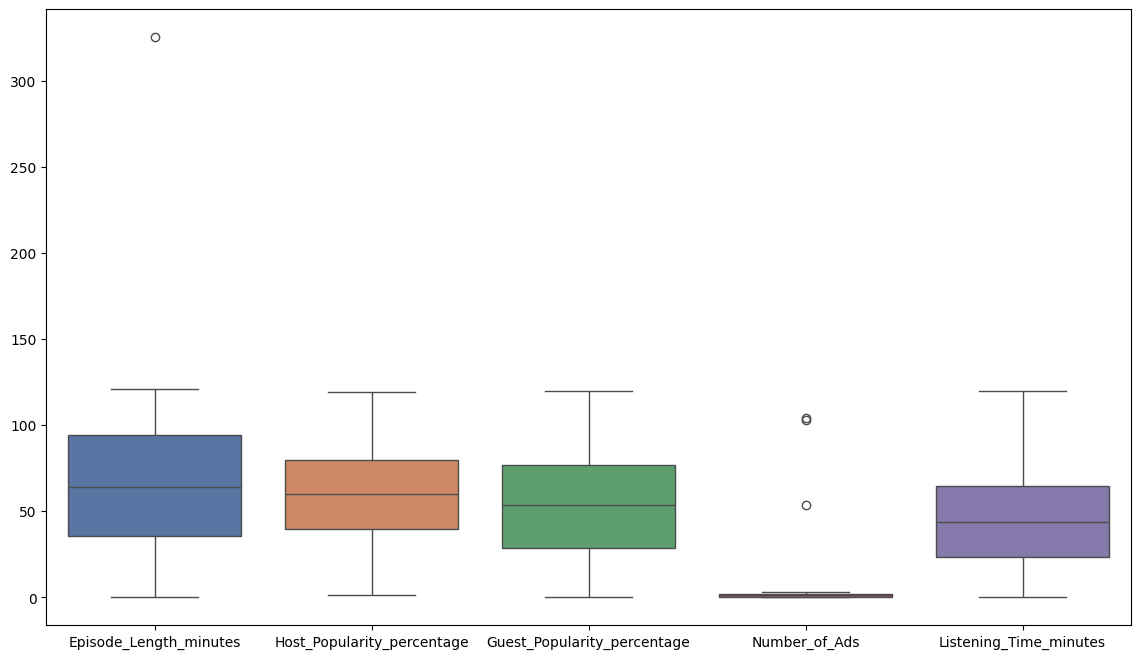

In [ ]:
#Look at numerical features

#box plot for train data
plt.figure(figsize =(14,8))
sns.boxplot(train_data.drop(["id"],axis = 1) ,palette ="deep")
plt.show()


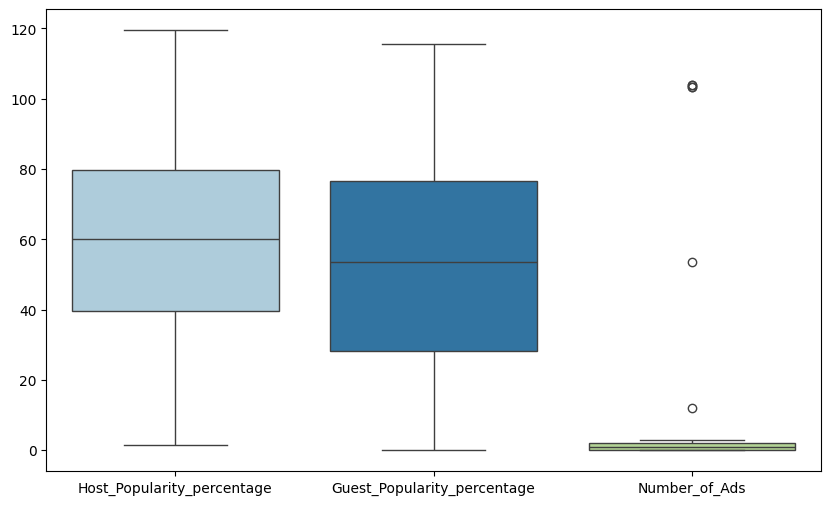

In [ ]:
#box plot for test data
plt.figure(figsize =(10,6))
sns.boxplot(test_data.drop(["id","Episode_Length_minutes"],axis = 1) ,palette ="Paired")
plt.show()

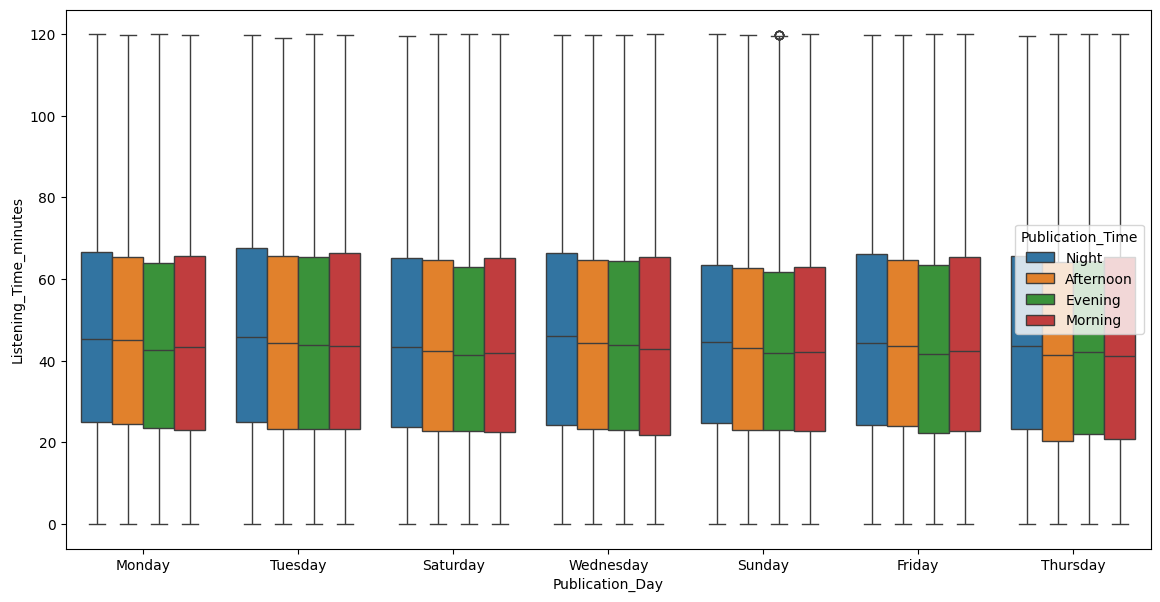

In [ ]:
plt.figure(figsize = (14,7))
sns.boxplot(x= "Publication_Day" ,y= "Listening_Time_minutes", hue = "Publication_Time", data = train_data)
plt.show()

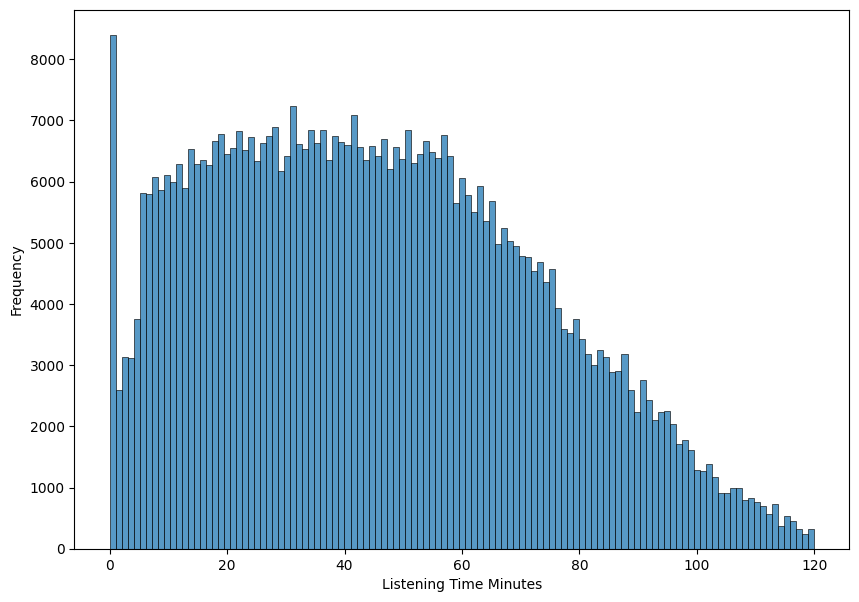

In [ ]:
plt.figure(figsize = (10,7))
sns.histplot(train_data["Listening_Time_minutes"])
plt.xlabel("Listening Time Minutes")
plt.ylabel("Frequency")
plt.show()

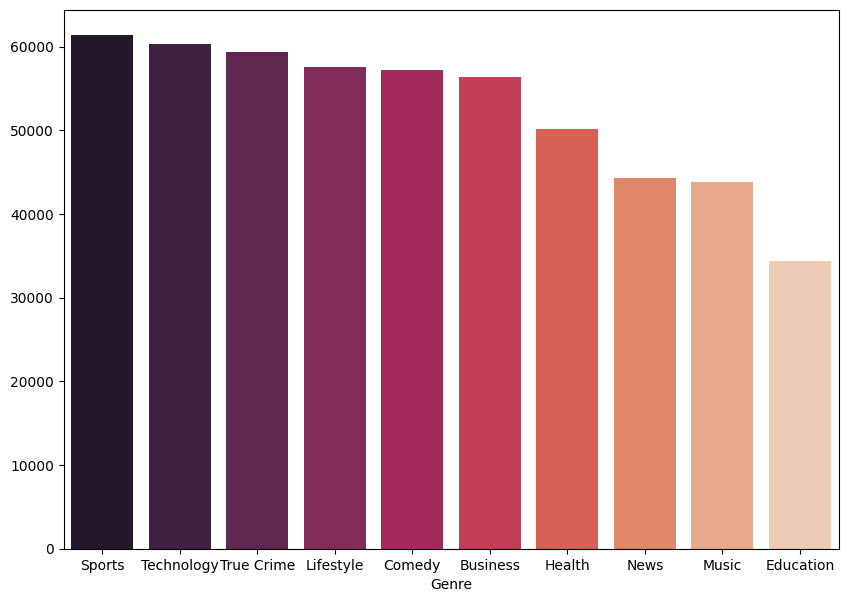

In [ ]:
#Look at categorical features
plt.figure(figsize = (10,7))
top_categories = train_data["Genre"].value_counts().nlargest(10)
sns.barplot(x=top_categories.index, y=top_categories.values,palette = "rocket")
plt.show()

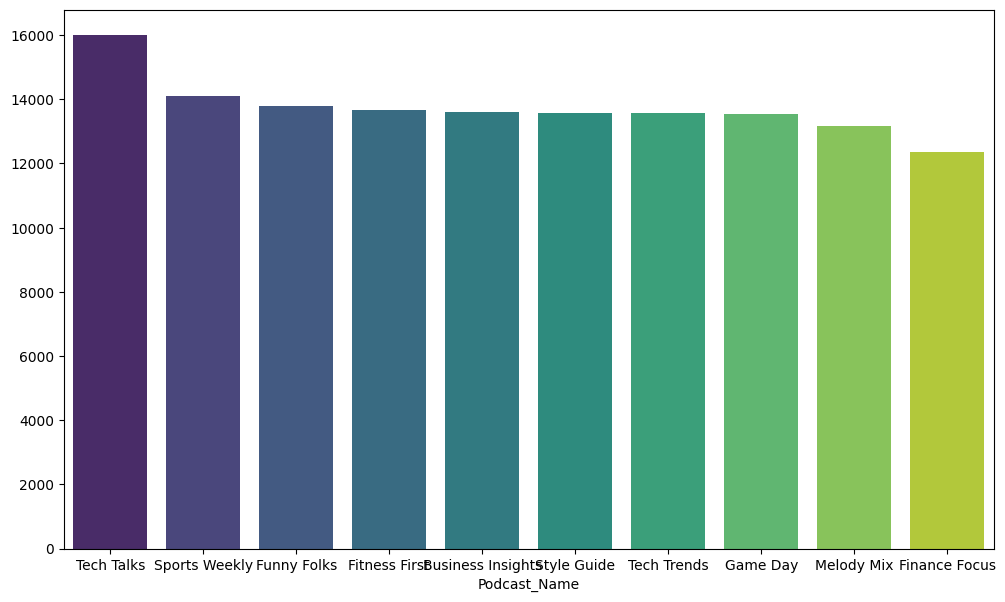

In [ ]:
plt.figure(figsize = (12,7))
top_categories = train_data["Podcast_Name"].value_counts().nlargest(10)
sns.barplot(x=top_categories.index, y=top_categories.values,palette = "viridis")
plt.show()

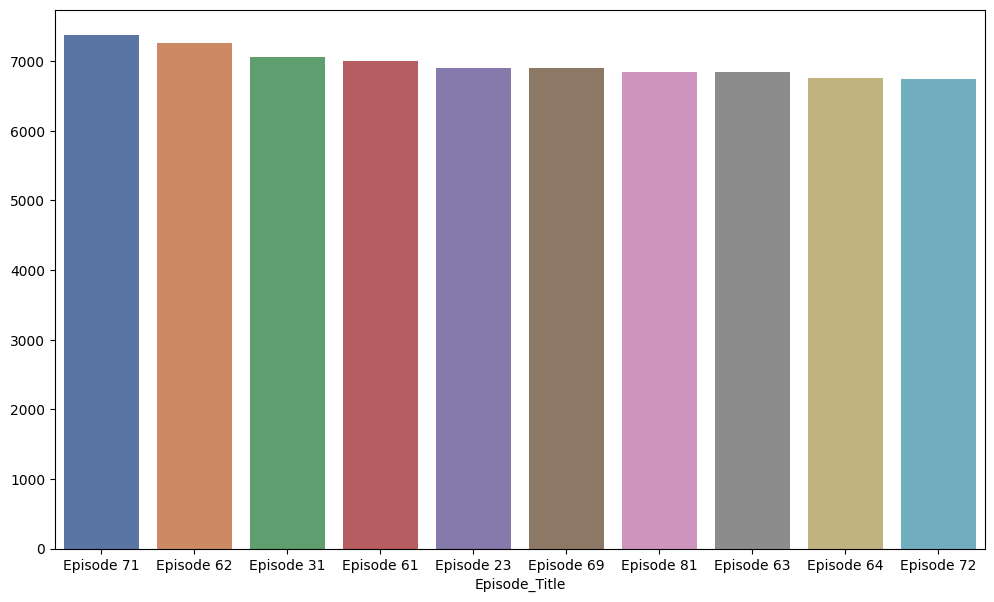

In [ ]:
plt.figure(figsize = (12,7))
top_categories = train_data["Episode_Title"].value_counts().nlargest(10)
sns.barplot(x=top_categories.index, y=top_categories.values,palette = "deep")
plt.show()

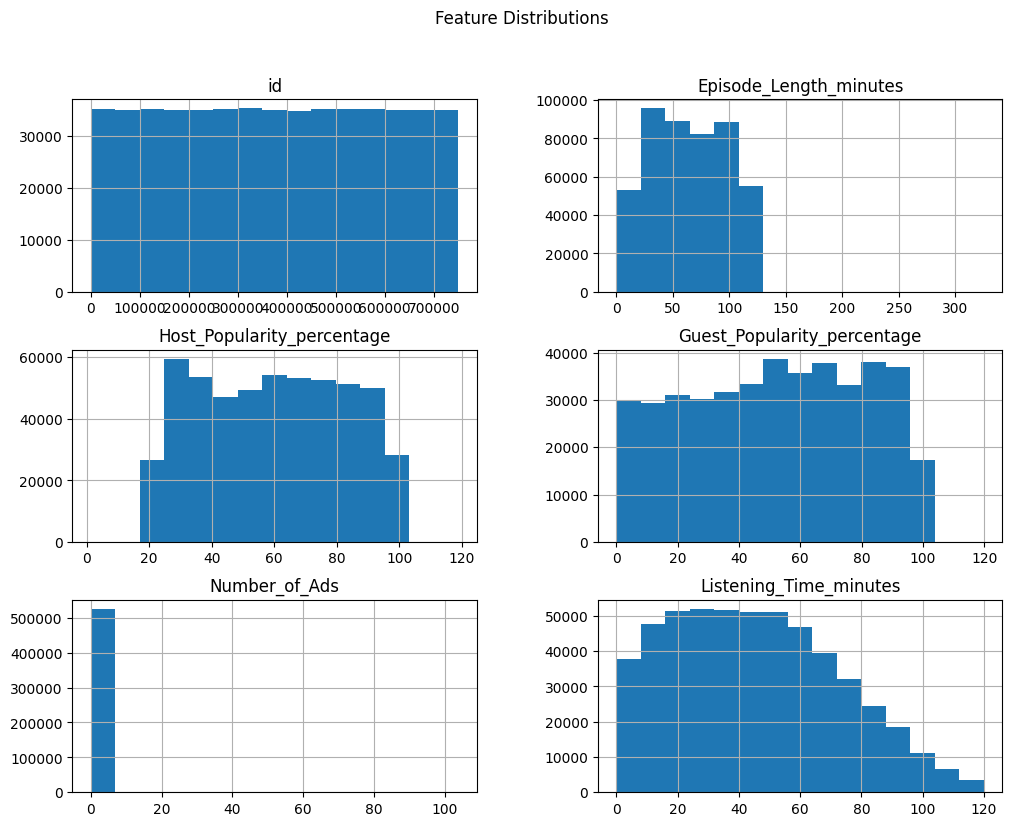

In [ ]:
train_data.hist(figsize=(12, 9), bins=15)
plt.suptitle("Feature Distributions")
plt.show()

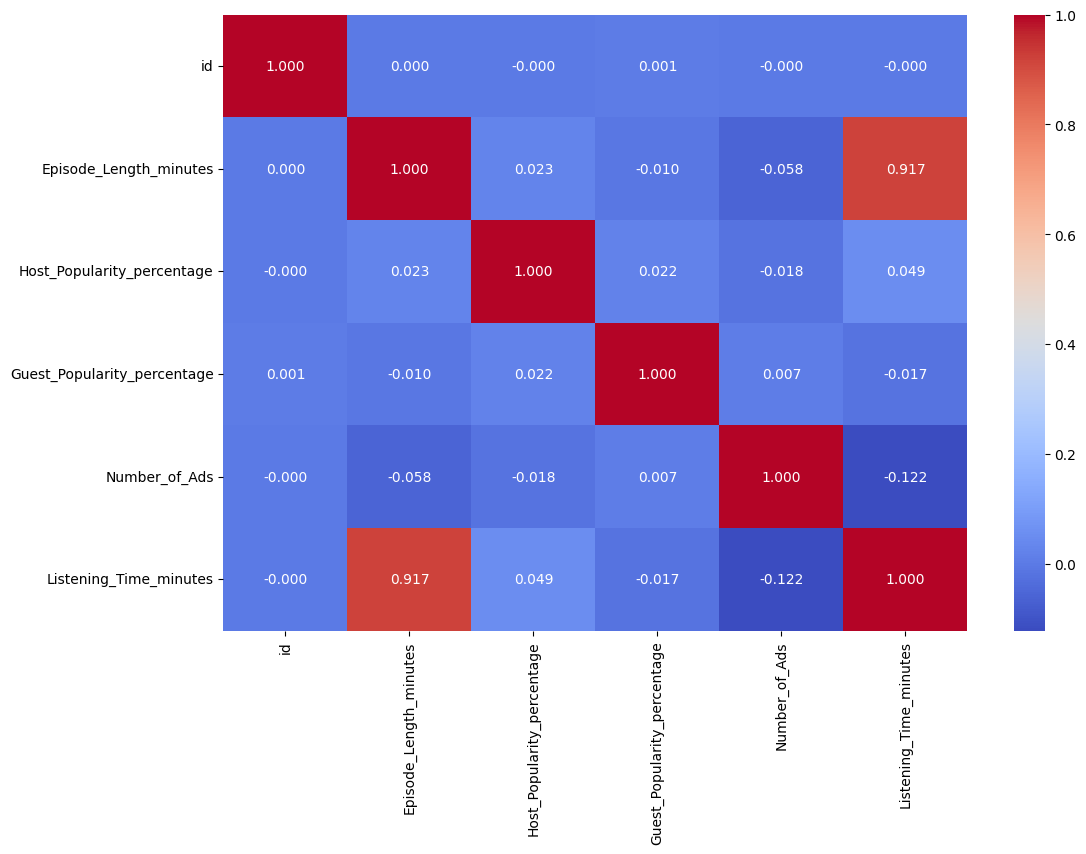

In [ ]:
#Correlation analysis
corr = train_data.select_dtypes(["int64","float64"]).corr()
plt.figure(figsize =(12,8))
sns.heatmap(corr,annot = True,cmap ="coolwarm",fmt = ".3f")
plt.show()

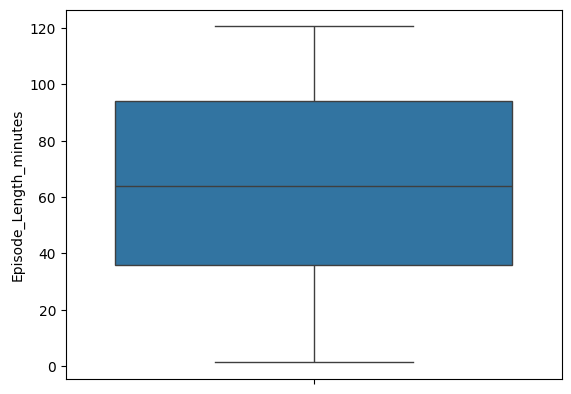

In [ ]:
#further checking for outliers.
sns.boxplot(test_data["Episode_Length_minutes"])
plt.show()

In [ ]:
#Performing outlier deduction

#Train Episode Lenght Minutes
Q3 = train_data["Episode_Length_minutes"].quantile(0.75)
Q1 = train_data["Episode_Length_minutes"].quantile(0.25)
IQR = Q3 - Q1
Upper_limit = Q3 + 1.5 * IQR

In [ ]:
outlier = train_data["Episode_Length_minutes"] > Upper_limit
train_data.loc[outlier, "Episode_Length_minutes"] = train_data["Episode_Length_minutes"].mean()

In [ ]:
#Train Number_of_Ads

Q3 = train_data["Number_of_Ads"].quantile(0.75)
Q1 = train_data["Number_of_Ads"].quantile(0.25)
IQR = Q3 - Q1
Upper_limit = Q3 + 1.5 * IQR

In [ ]:
outlier = train_data["Number_of_Ads"] > Upper_limit
train_data.loc[outlier, "Number_of_Ads"] = train_data["Number_of_Ads"].mean()

In [ ]:
#Test Number_of_Ads
Q3 = test_data["Number_of_Ads"].quantile(0.75)
Q1 = test_data["Number_of_Ads"].quantile(0.25)
IQR = Q3 - Q1
Upper_limit = Q3 + 1.5 * IQR


In [ ]:
outlier = test_data["Number_of_Ads"] > Upper_limit
test_data.loc[outlier, "Number_of_Ads"] = test_data["Number_of_Ads"].mean()

In [ ]:
#Test episode length minutes
Q3 = test_data["Episode_Length_minutes"].quantile(0.75)
Q1 = test_data["Episode_Length_minutes"].quantile(0.25)
IQR = Q3 - Q1
Upper_limit = Q3 + 3 * IQR

In [ ]:
outlier = test_data["Episode_Length_minutes"] > Upper_limit
test_data.loc[outlier, "Episode_Length_minutes"] = test_data["Episode_Length_minutes"].mean()

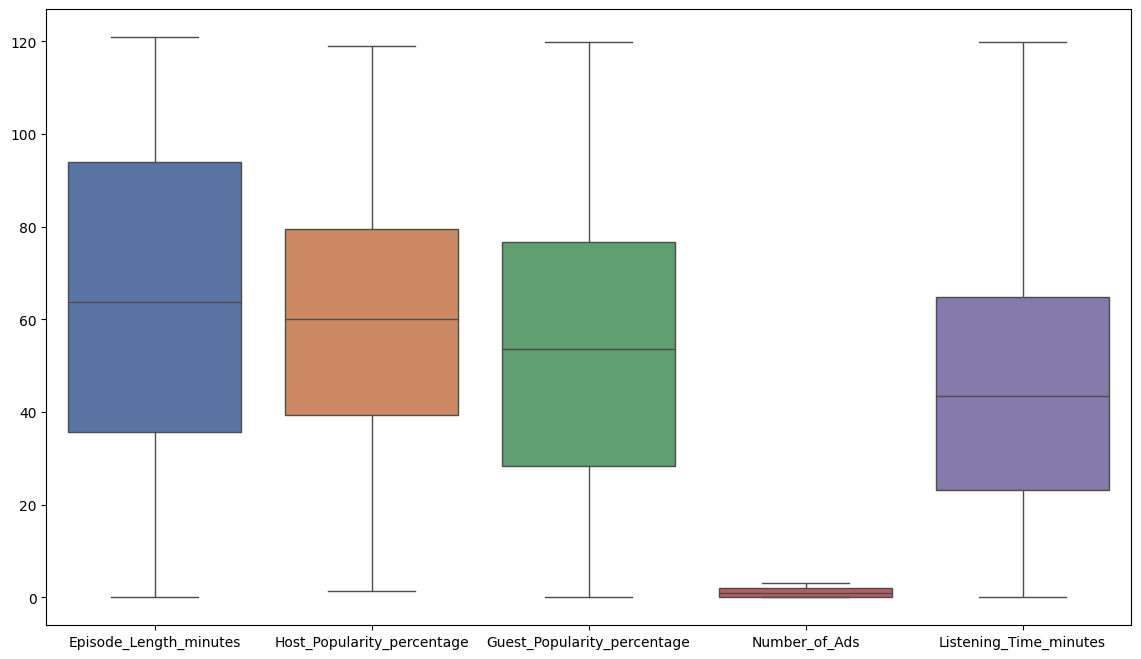

In [ ]:
plt.figure(figsize =(14,8))
sns.boxplot(train_data.drop(["id"],axis = 1) ,palette ="deep")
plt.show()

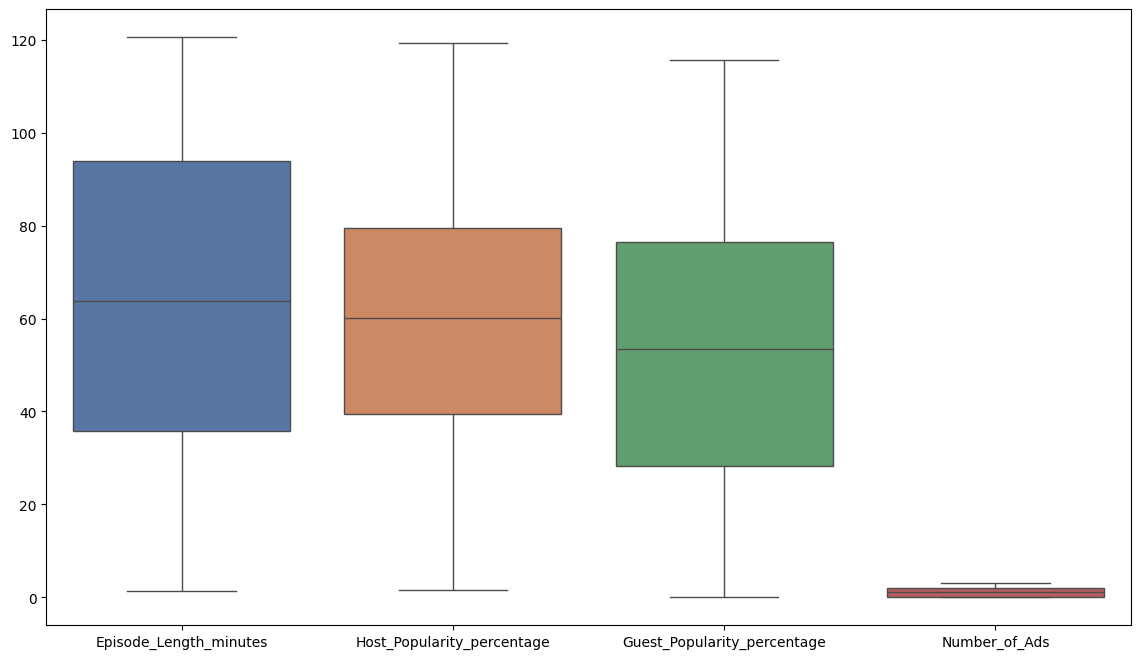

In [ ]:
plt.figure(figsize =(14,8))
sns.boxplot(test_data.drop(["id"],axis = 1) ,palette ="deep")
plt.show()

In [ ]:
#Feature Engineering

#Checking for Null values
print(train_data.isnull().sum())
print("----------------------------------------------------------")
print(test_data.isnull().sum())

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          60886
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    102218
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64
----------------------------------------------------------
id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         26207
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    43812
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64


In [ ]:
print(train_data.isnull().sum()/ len(train_data) * 100)
print("----------------------------------------------------------")
print(test_data.isnull().sum()/ len(train_data) * 100)

id                              0.000000
Podcast_Name                    0.000000
Episode_Title                   0.000000
Episode_Length_minutes         11.597333
Genre                           0.000000
Host_Popularity_percentage      0.000000
Publication_Day                 0.000000
Publication_Time                0.000000
Guest_Popularity_percentage    19.470095
Number_of_Ads                   0.000190
Episode_Sentiment               0.000000
Listening_Time_minutes          0.000000
dtype: float64
----------------------------------------------------------
id                             0.000000
Podcast_Name                   0.000000
Episode_Title                  0.000000
Episode_Length_minutes         4.991810
Genre                          0.000000
Host_Popularity_percentage     0.000000
Publication_Day                0.000000
Publication_Time               0.000000
Guest_Popularity_percentage    8.345143
Number_of_Ads                  0.000000
Episode_Sentiment              0.0

In [ ]:
train_data['Number_of_Ads'].fillna(train_data['Number_of_Ads'].median(), inplace=True)

train_data['Episode_Length_minutes'].fillna(train_data['Episode_Length_minutes'].median(), inplace=True)
test_data['Episode_Length_minutes'].fillna(test_data['Episode_Length_minutes'].median(), inplace=True)

train_data['Guest_Popularity_percentage'].fillna(train_data['Guest_Popularity_percentage'].median(), inplace=True)
test_data['Guest_Popularity_percentage'].fillna(test_data['Guest_Popularity_percentage'].median(), inplace=True)

In [ ]:
train_data["Text_Length_Name"] = train_data["Podcast_Name"].apply(len)
test_data["Text_Length_Name"] = test_data["Podcast_Name"].apply(len)


def create_meaningful_arithmetic_features(df):
    epsilon = 1e-6

    df['Host_Popularity_per_Minute'] = df['Host_Popularity_percentage'] / (df['Episode_Length_minutes'] + epsilon)
    df['Guest_Popularity_per_Minute'] = df['Guest_Popularity_percentage'] / (df['Episode_Length_minutes'] + epsilon)

    df['Ads_per_Minute'] = df['Number_of_Ads'] / (df['Episode_Length_minutes'] + epsilon)

    df['Host_Guest_Popularity_Ratio'] = (df['Host_Popularity_percentage'] + epsilon) / (df['Guest_Popularity_percentage'] + epsilon)
    df['Guest_Host_Popularity_Ratio'] = (df['Guest_Popularity_percentage'] + epsilon) / (df['Host_Popularity_percentage'] + epsilon)

    df['Total_Popularity'] = df['Host_Popularity_percentage'] + df['Guest_Popularity_percentage']

    df['Popularity_Difference'] = df['Host_Popularity_percentage'] - df['Guest_Popularity_percentage']

    df['Ads_per_Host_Popularity'] = df['Number_of_Ads'] / (df['Host_Popularity_percentage'] + epsilon)
    df['Ads_per_Guest_Popularity'] = df['Number_of_Ads'] / (df['Guest_Popularity_percentage'] + epsilon)

    return df

train_data = create_meaningful_arithmetic_features(train_data.copy())
test_data = create_meaningful_arithmetic_features(test_data.copy())

In [ ]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,...,Text_Length_Name,Host_Popularity_per_Minute,Guest_Popularity_per_Minute,Ads_per_Minute,Host_Guest_Popularity_Ratio,Guest_Host_Popularity_Ratio,Total_Popularity,Popularity_Difference,Ads_per_Host_Popularity,Ads_per_Guest_Popularity
480590,480590,Tech Trends,Episode 34,66.33,Technology,65.83,Monday,Night,29.10,1.0,...,11,0.992462,0.438716,0.015076,2.262199,0.442048,94.93,36.73,0.015191,0.034364
214314,214314,Mind & Body,Episode 42,75.03,Health,87.79,Tuesday,Afternoon,41.99,1.0,...,11,1.170065,0.559643,0.013328,2.090736,0.478300,129.78,45.80,0.011391,0.023815
685056,685056,Mind & Body,Episode 86,112.65,Health,31.81,Saturday,Night,26.79,0.0,...,11,0.282379,0.237816,0.000000,1.187383,0.842188,58.60,5.02,0.000000,0.000000
174411,174411,Gadget Geek,Episode 69,111.41,Technology,51.89,Wednesday,Night,90.31,2.0,...,11,0.465757,0.810609,0.017952,0.574576,1.740412,142.20,-38.42,0.038543,0.022146
501789,501789,Sound Waves,Episode 64,59.07,Music,83.49,Wednesday,Night,69.13,1.0,...,11,1.413408,1.170306,0.016929,1.207725,0.828003,152.62,14.36,0.011977,0.014465


In [ ]:
#feature scaling
X = train_data.drop(["id","Listening_Time_minutes","Podcast_Name","Episode_Title"],axis=1)
y = train_data["Listening_Time_minutes"]
X_test = test_data.drop(["id","Podcast_Name","Episode_Title"],axis=1)

numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_cols)

In [ ]:
#feature encoding

train_data['Is_Episode_Length_Missing'] = train_data['Episode_Length_minutes'].isnull().astype(int)
test_data['Is_Episode_Length_Missing'] = test_data['Episode_Length_minutes'].isnull().astype(int)

train_data['Is_Guest_Popularity_Missing'] = train_data['Guest_Popularity_percentage'].isnull().astype(int)
test_data['Is_Guest_Popularity_Missing'] = test_data['Guest_Popularity_percentage'].isnull().astype(int)

In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
pref = ["Gen","Day","Time","Sent"]

X_train_encode = pd.get_dummies(data = X ,columns =  categorical_cols, prefix = pref,drop_first = True)
X_test_encode = pd.get_dummies(data = X_test,columns = categorical_cols,prefix = pref,drop_first=True)

bool_columns = X_train_encode.select_dtypes(include = "bool").columns
X_train_encode[bool_columns] = X_train_encode[bool_columns].astype(int)

bool_columns = X_test_encode.select_dtypes(include = "bool").columns
X_test_encode[bool_columns] = X_test_encode[bool_columns].astype(int)

In [ ]:
X_categorical = X_train_encode.drop(numeric_cols, axis=1)
X_train_final = pd.concat([X_scaled_df, X_categorical.reset_index(drop=True)], axis=1)

X_categorical_test = X_test_encode.drop(numeric_cols, axis=1)
X_scaled_test_final = pd.concat([X_test_scaled_df, X_categorical_test.reset_index(drop=True)], axis=1)

In [ ]:
#Machine learning

#XGBOOST
xgb_model = XGBRegressor(random_state = 42,colsample_bytree = 0.7,gamma =1,learning_rate = 0.05,max_depth= 10,n_estimators = 1000,subsample = 0.8,reg_lambda = 0.1,reg_alpha = 10)

In [ ]:
scores = cross_val_score(xgb_model, X_train_final, y, cv=5, scoring='neg_root_mean_squared_error')
rmse_scores = np.abs(scores)
print(f" Mean RMSE scores: {rmse_scores.mean():.4f}")

 Mean RMSE scores: 12.9314


In [ ]:
xgb_model.fit(X_train_final , y)
y_test_pred = xgb_model.predict(X_scaled_test_final)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Test-set RMSE   : {test_rmse:.4f}")

Test-set RMSE   : 12.9425


In [ ]:
#lasso model

lasso_model = Lasso(random_state = 42,alpha=  0.001, max_iter=1000, selection='cyclic', tol= 0.01)
scores = cross_val_score(lasso_model, X_train_final, y, cv=5, scoring='neg_root_mean_squared_error')
rmse_scores = np.abs(scores)
print(f"Mean RMSE: {rmse_scores.mean():.4f}")

Mean RMSE: 13.3136


In [ ]:
lasso_model.fit(X_train_final , y)
y_test_pred = lasso_model.predict(X_scaled_test_final)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Test‐set RMSE: {test_rmse:.4f}")

Test‐set RMSE: 13.3558


In [ ]:
#ANN model
ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    alpha=0.001,
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

In [ ]:
ann_model.fit(X_train_final, y)
y_test_pred = ann_model.predict(X_scaled_test_final)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Test-set RMSE: {test_rmse:.4f}")

Test-set RMSE: 13.2697


In [ ]:
#Voting regressor

#XGBOOST + ANN
xgb_model = XGBRegressor(random_state = 42,colsample_bytree = 0.7,gamma =1,learning_rate = 0.05,max_depth= 10,n_estimators = 1000,subsample = 0.8,reg_lambda = 0.1,reg_alpha = 10)
ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    alpha=0.001,
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

voting = VotingRegressor(
    estimators=[
        ('xgb', xgb_model),
        ('mlp', ann_model)
    ],
    n_jobs=-1
)

voting.fit(X_train_final, y)
y_test_pred = voting.predict(X_scaled_test_final)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Voting Regressor Test-set RMSE: {test_rmse:.4f}")

Voting Regressor Test-set RMSE: 12.9753
